In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Loading product data, keep only relevant columns
product_df = pd.read_csv("product_info.csv")
product_df = product_df[["product_id", "product_name", "loves_count", "rating", "reviews", "ingredients", "price_usd", "highlights", "primary_category", "secondary_category", "tertiary_category"]]

product_df.info()
product_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          8494 non-null   object 
 1   product_name        8494 non-null   object 
 2   loves_count         8494 non-null   int64  
 3   rating              8216 non-null   float64
 4   reviews             8216 non-null   float64
 5   ingredients         7549 non-null   object 
 6   price_usd           8494 non-null   float64
 7   highlights          6287 non-null   object 
 8   primary_category    8494 non-null   object 
 9   secondary_category  8486 non-null   object 
 10  tertiary_category   7504 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 730.1+ KB


,product_id,product_name,loves_count,rating,reviews,ingredients,price_usd,highlights,primary_category,secondary_category,tertiary_category
0,P473671,Fragrance Discovery Set,6320,3.6364,11.0,"['Capri Eau de Parfum:', 'Alcohol Denat. (SD A...",35.0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets
1,P473668,La Habana Eau de Parfum,3827,4.1538,13.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume
2,P473662,Rainbow Bar Eau de Parfum,3253,4.2500,16.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume
3,P473660,Kasbah Eau de Parfum,3018,4.4762,21.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume
4,P473658,Purple Haze Eau de Parfum,2691,3.2308,13.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume


In [2]:
#Loading and concatenating all reviews datasets, keep only relevant columns
reviews1 = pd.read_csv("reviews_0-250.csv")
reviews2 = pd.read_csv("reviews_250-500.csv")
reviews3 = pd.read_csv("reviews_500-750.csv")
reviews4 = pd.read_csv("reviews_750-1250.csv")
reviews5 = pd.read_csv("reviews_1250-end.csv")

reviews_df = pd.concat(
    [reviews1, reviews2, reviews3, reviews4, reviews5],
    ignore_index=True
)

reviews_df = reviews_df.drop_duplicates()
reviews_df = reviews_df[["product_id", "product_name", "rating", "is_recommended", "total_feedback_count", "total_pos_feedback_count", "review_text"]]

reviews_df.info()
reviews_df.head()

/var/folders/yg/7mhh_1wj4_d_5kz_40xdnj7c0000gn/T/ipykernel_31386/1008845895.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews1 = pd.read_csv("reviews_0-250.csv")
/var/folders/yg/7mhh_1wj4_d_5kz_40xdnj7c0000gn/T/ipykernel_31386/1008845895.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews4 = pd.read_csv("reviews_750-1250.csv")
/var/folders/yg/7mhh_1wj4_d_5kz_40xdnj7c0000gn/T/ipykernel_31386/1008845895.py:6: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews5 = pd.read_csv("reviews_1250-end.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094411 entries, 0 to 1094410
Data columns (total 7 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   product_id                1094411 non-null  object 
 1   product_name              1094411 non-null  object 
 2   rating                    1094411 non-null  int64  
 3   is_recommended            926423 non-null   float64
 4   total_feedback_count      1094411 non-null  int64  
 5   total_pos_feedback_count  1094411 non-null  int64  
 6   review_text               1092967 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 58.4+ MB


,product_id,product_name,rating,is_recommended,total_feedback_count,total_pos_feedback_count,review_text
0,P504322,Gentle Hydra-Gel Face Cleanser,5,1.0,2,2,I use this with the Nudestix “Citrus Clean Bal...
1,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,1,0.0,0,0,I bought this lip mask after reading the revie...
2,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,5,1.0,0,0,My review title says it all! I get so excited ...
3,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,5,1.0,0,0,I’ve always loved this formula for a long time...
4,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,5,1.0,0,0,"If you have dry cracked lips, this is a must h..."


In [3]:
#Filter for only skincare in products dataset
product_df = product_df[
    product_df["primary_category"].str.contains("Skincare", case=False, na=False)|
    product_df["secondary_category"].str.contains("Skincare", case=False, na=False)|
    product_df["tertiary_category"].str.contains("Skincare", case=False, na=False)
]

reviews_df = reviews_df[reviews_df['product_id'].isin(product_df['product_id'])]
print(product_df.shape)
print(reviews_df.shape)

reviews_df['product_id'].value_counts()

(2522, 11)
(1094411, 7)


product_id
P420652    16138
P7880       8736
P218700     7763
P248407     7547
P269122     7414
           ...  
P501153        1
P504424        1
P480445        1
P501886        1
P504322        1
Name: count, Length: 2351, dtype: int64

In [4]:
#Check for null values
print(product_df.isna().sum())
print(reviews_df.isna().sum())

product_id              0
product_name            0
loves_count             0
rating                 73
reviews                73
ingredients           143
price_usd               0
highlights            448
primary_category        0
secondary_category      0
tertiary_category     446
dtype: int64
product_id                       0
product_name                     0
rating                           0
is_recommended              167988
total_feedback_count             0
total_pos_feedback_count         0
review_text                   1444
dtype: int64


In [5]:
#Drop null rows that may affect analysis
product_df = product_df[product_df["rating"].notna()]
product_df = product_df[product_df["ingredients"].notna()]

reviews_df = reviews_df[reviews_df["is_recommended"].notna()]

In [6]:
print("Products:", product_df.shape)
print("Unique Products:", product_df["product_id"].nunique())

print("Reviews:", reviews_df.shape)
print("Unique Reviewed Products:", reviews_df["product_id"].nunique())

Products: (2313, 11)
Unique Products: 2313
Reviews: (926423, 7)
Unique Reviewed Products: 2351


In [7]:
#Remove mini size products
product_df = product_df[~(
        product_df["primary_category"].str.contains("Mini Size", case=False, na=False)|
        product_df["secondary_category"].str.contains("Mini Size", case=False, na=False)|
        product_df["tertiary_category"].str.contains("Mini Size", case=False, na=False)
    )
]

#Update reviews dataset for removed products
reviews_df = reviews_df[reviews_df["product_id"].isin(product_df["product_id"])]

In [8]:
#Clean price data, create price bands
product_df = product_df[(product_df["price_usd"].notna()) & (product_df["price_usd"] > 0)]
product_df["price_band"] = pd.cut(
    product_df["price_usd"],
    bins=[0, 20, 40, 60, 80, 200],
    labels=["0–20", "20–40", "40–60", "60–80", "80+"]
)

#Update reviews dataset for removed products
reviews_df = reviews_df[reviews_df["product_id"].isin(product_df["product_id"])]

In [9]:
#Aggregate reviews to product level
review_agg = reviews_df.groupby("product_id").agg(
    total_reviews=("rating", "count"),
    recommend_rate=("is_recommended", "mean"),
    total_positive=("total_pos_feedback_count", "sum"),
    total_feedback=("total_feedback_count", "sum")
).reset_index()

review_agg["positive_feedback_ratio"] = (review_agg["total_positive"] / review_agg["total_feedback"])

In [10]:
#Merge aggregated reviews with products, drop products with no reviews
final_df = product_df.merge(review_agg, on="product_id", how="left")
final_df = final_df[final_df["total_reviews"].notna()]

final_df.shape

(2117, 17)

In [11]:
#Determining a minimum review threshold by looking at distribution (how many reviews products have on avg)
final_df["total_reviews"].describe()
final_df["total_reviews"].quantile([0.1, 0.25, 0.5, 0.75, 0.9])

for n in [1, 5, 10, 15, 20, 35]:
    count = (final_df["total_reviews"] < n).sum()
    print(f"Products with < {n} reviews: {count}")

Products with < 1 reviews: 0
Products with < 5 reviews: 118
Products with < 10 reviews: 209
Products with < 15 reviews: 303
Products with < 20 reviews: 382
Products with < 35 reviews: 529


In [12]:
#Setting minimum review threshold at 10 
final_df = final_df[final_df["total_reviews"] >= 10]

print("Final dataset shape:", final_df.shape)
print("Unique products:", final_df["product_id"].nunique())

Final dataset shape: (1908, 17)
Unique products: 1908


In [13]:
final_df

,product_id,product_name,loves_count,rating,reviews,ingredients,price_usd,highlights,primary_category,secondary_category,tertiary_category,price_band,total_reviews,recommend_rate,total_positive,total_feedback,positive_feedback_ratio
0,P439055,GENIUS Sleeping Collagen Moisturizer,33910,4.5413,1321.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Ethylh...",98.0,"['Vegan', 'Good for: Loss of firmness', 'Colla...",Skincare,Moisturizers,Moisturizers,80+,1321.0,0.920515,2798.0,3467.0,0.807038
1,P421277,GENIUS Liquid Collagen Serum,67870,4.0259,1159.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Propan...",115.0,"['Vegan', 'Good for: Loss of firmness', 'Colla...",Skincare,Treatments,Face Serums,80+,1126.0,0.762877,8131.0,10025.0,0.811072
2,P467602,Triple Algae Eye Renewal Balm Eye Cream,17890,4.5306,1142.0,"['Aqua (Water/Eau), Stearic Acid, Isopropyl Is...",68.0,NaN,Skincare,Eye Care,Eye Creams & Treatments,60–80,1142.0,0.938704,1330.0,1730.0,0.768786
3,P432045,GENIUS Liquid Collagen Lip Treatment,44448,3.8721,649.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Glycer...",29.0,"['Vegan', 'Good for: Loss of firmness', 'Plump...",Skincare,Lip Balms & Treatments,NaN,20–40,649.0,0.713405,4527.0,5413.0,0.836320
4,P311143,SUBLIME DEFENSE Ultra Lightweight UV Defense F...,27278,4.4134,508.0,"['Octinoxate 7.5%, Titanium Dioxide 2%, Zinc O...",28.0,"['Vegan', 'Hypoallergenic', 'UV Protection', '...",Skincare,Sunscreen,Face Sunscreen,20–40,232.0,0.814655,698.0,803.0,0.869240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2143,P416923,Superfood Hydrate + Firm Peptide Eye Cream,38812,3.6564,326.0,"['Water/Aqua/Eau (Aqua), Helianthus Annuus (Su...",38.0,"['Hyaluronic Acid', 'Good for: Loss of firmnes...",Skincare,Eye Care,Eye Creams & Treatments,20–40,287.0,0.609756,1547.0,1964.0,0.787678
2144,P482329,Retinal + Niacinamide Youth Serum,41445,4.5841,315.0,"['Water/Aqua/Eau, Butylene Glycol, Triethylhex...",69.0,"['Good for: Dullness/Uneven Texture', 'Clean +...",Skincare,Treatments,Face Serums,60–80,317.0,0.940063,680.0,1066.0,0.637899
2145,P502479,Kombucha + 10% AHA Liquid Exfoliant with Lacti...,11299,4.5926,81.0,"['Water/Aqua/Eau, Pentylene Glycol, Lactic Aci...",42.0,"['Good for: Dullness/Uneven Texture', 'Lactic ...",Skincare,Cleansers,Exfoliators,40–60,82.0,0.926829,130.0,170.0,0.764706
2146,P473336,The Youth System,53522,4.5526,76.0,"['Superfood Antioxidant Cleanser:', 'Water/Aqu...",59.0,"['Vegan', 'Vitamin C', 'Good for: Pores', 'Cle...",Skincare,Value & Gift Sets,NaN,40–60,77.0,0.896104,522.0,714.0,0.731092


In [14]:
final_df.to_csv("cleaned_dataset.csv", index=False)

**Price Bands vs Customer Satisfaction**

In [ ]:
# group to product level
product_df = final_df.groupby('product_id').agg(
    price_usd=('price_usd', 'first'),     # taking the price
    recommendation_rate=('recommend_rate', 'mean'),     # calculate average recommendation
    total_reviews=('total_reviews', 'first'),      # Use 'first' to get the already calculated total reviews
    rating=('rating', 'mean'), # Include rating in the aggregation
    product_name=('product_name', 'first') # Include product_name in the aggregation
).reset_index()

In [ ]:
print("Total reviews per product:")
display(final_df[['product_id', 'product_name', 'total_reviews']].head())

print("\nSummary statistics for total reviews:")
display(final_df['total_reviews'].describe())

Total reviews per product:


,product_id,product_name,total_reviews
0,P439055,GENIUS Sleeping Collagen Moisturizer,1321.0
1,P421277,GENIUS Liquid Collagen Serum,1126.0
2,P467602,Triple Algae Eye Renewal Balm Eye Cream,1142.0
3,P432045,GENIUS Liquid Collagen Lip Treatment,649.0
4,P311143,SUBLIME DEFENSE Ultra Lightweight UV Defense F...,232.0



Summary statistics for total reviews:


,total_reviews
count,1466.000000
mean,561.929059
std,850.484923
min,50.000000
25%,139.000000
50%,296.500000
75%,624.750000
max,15899.000000


In [ ]:
products_over_100 = final_df[final_df['total_reviews'] > 50]
print(f"Number of products with more than 100 reviews: {len(products_over_100)}")

Number of products with more than 100 reviews: 1463


In [ ]:
product_df = product_df[product_df['total_reviews'] > 50]

# looking to see which products have 50+ reviews -- but this can be changed at any point

In [ ]:
product_df["price_band"] = pd.cut(
    product_df["price_usd"],
    bins=[0, 20, 40, 60, 80, 200],
    labels=["0–20", "20–40", "40–60", "60–80", "80+"]
)

print("New price bands applied to product_df:")
display(product_df[['product_name', 'price_usd', 'price_band']].head())

New price bands applied to product_df:


,product_name,price_usd,price_band
0,Renewing Eye Cream,89.0,80+
1,Goodbye Acne Max Complexion Correction Pads,48.0,40–60
2,Grape Water Moisturizing Face Mist,12.0,0–20
3,7 Day Face Scrub Cream Rinse-Off Formula,26.0,20–40
4,Exfoliating Face Scrub,26.0,20–40


In [ ]:
price_summary_specific_bins = product_df.groupby('price_band', observed=True)['recommendation_rate'].agg(
    ['mean', 'std', 'count']
)

print("Price Summary with specific bins:")
print(price_summary_specific_bins)

Price Summary with specific bins:
                mean       std  count
price_band                           
0–20        0.799614  0.111842    201
20–40       0.834301  0.097890    465
40–60       0.854232  0.093359    368
60–80       0.863408  0.097853    226
80+         0.854567  0.112288    173


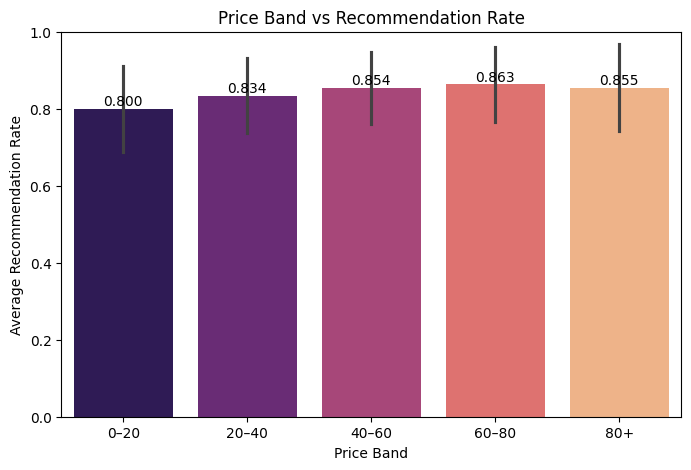

In [ ]:
plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=product_df,
    x='price_band',
    y='recommendation_rate',
    errorbar='sd',           # show standard deviation as error bars
    palette='magma',
    hue='price_band',
    legend=False
)
plt.title('Price Band vs Recommendation Rate')
plt.xlabel('Price Band')
plt.ylabel('Average Recommendation Rate')
plt.ylim(0,1)         # since recommendation rate is 0-1

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f') # Use 3 decimal places for recommendation rate

plt.show()

In [ ]:
# Analyze average rating by price band
rating_summary = product_df.groupby('price_band', observed=True)['rating'].agg(
    ['mean', 'std', 'count']
)

print("Average Rating by Price Band:")
print(rating_summary)

Average Rating by Price Band:
                mean       std  count
price_band                           
0–20        4.155057  0.402055    201
20–40       4.285557  0.328656    465
40–60       4.358885  0.302238    368
60–80       4.373017  0.314489    226
80+         4.357936  0.370277    173


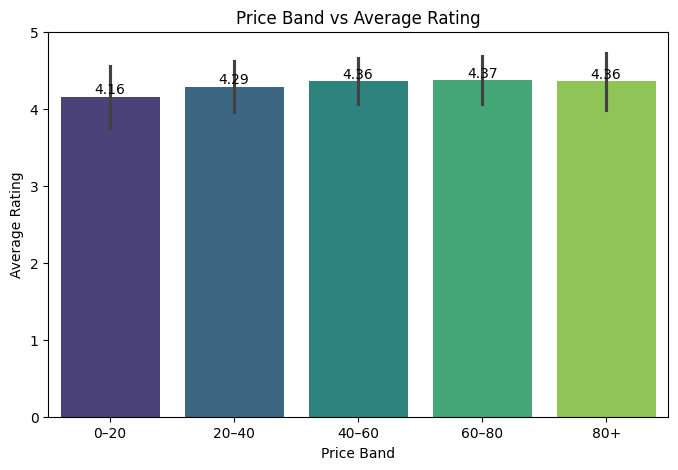

In [ ]:
# Visualize average rating by price band
plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=product_df,
    x='price_band',
    y='rating',
    errorbar='sd',           # show standard deviation as error bars
    palette='viridis',
    hue='price_band',
    legend=False
)
plt.title('Price Band vs Average Rating')
plt.xlabel('Price Band')
plt.ylabel('Average Rating')
plt.ylim(0, 5)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.show()

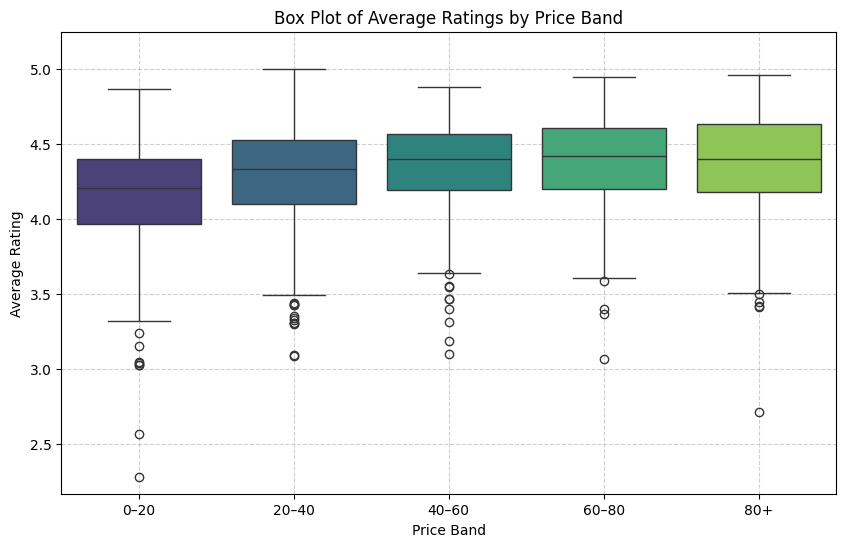

In [ ]:
# Visualize the distribution of average ratings across price bands using a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=product_df,
    x='price_band',
    y='rating',
    palette='viridis',
    hue='price_band', # Assign x variable to hue for clarity
    legend=False      # Set legend to False
)
plt.title('Box Plot of Average Ratings by Price Band')
plt.xlabel('Price Band')
plt.ylabel('Average Rating')
plt.ylim(product_df['rating'].min() * 0.95, product_df['rating'].max() * 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# Calculate the Pearson correlation coefficient
correlation = product_df['rating'].corr(product_df['recommendation_rate'])
print(f"Pearson Correlation between Average Rating and Recommendation Rate: {correlation:.4f}")

Pearson Correlation between Average Rating and Recommendation Rate: 0.9547


In [ ]:
product_df['normalized_rating'] = product_df['rating'] / 5.0
product_df['combined_satisfaction'] = (product_df['normalized_rating'] + product_df['recommendation_rate']) / 2

print(product_df[['rating', 'normalized_rating', 'recommendation_rate', 'combined_satisfaction']].head())

   rating  normalized_rating  recommendation_rate  combined_satisfaction
0  4.0316            0.80632             0.708861               0.757590
1  4.4199            0.88398             0.871314               0.877647
2  4.4431            0.88862             0.871795               0.880207
3  4.5321            0.90642             0.797753               0.852086
4  4.6122            0.92244             0.821012               0.871726


In [ ]:
combined_satisfaction_summary = product_df.groupby('price_band', observed=True)['combined_satisfaction'].agg(
    ['mean', 'std', 'count']
)

print("Combined Satisfaction Summary by Price Band:")
print(combined_satisfaction_summary)

Combined Satisfaction Summary by Price Band:
                mean       std  count
price_band                           
0–20        0.815313  0.095494    201
20–40       0.845706  0.080725    465
40–60       0.863005  0.076000    368
60–80       0.869006  0.079446    226
80+         0.863077  0.092080    173


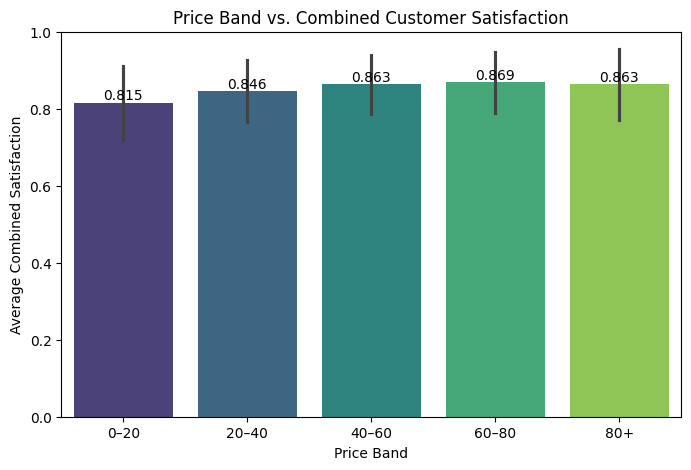

In [ ]:
plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=product_df,
    x='price_band',
    y='combined_satisfaction',
    errorbar='sd',
    palette='viridis',
    hue='price_band',
    legend=False
)
plt.title('Price Band vs. Combined Customer Satisfaction')
plt.xlabel('Price Band')
plt.ylabel('Average Combined Satisfaction')
plt.ylim(0,1)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.show()

**Ingredients vs Customer Satisfaction Using Average Ratings**

In [ ]:
import re

# Standardize ingredient text
product_df["ingredients_clean"] = (
    product_df["ingredients"]
    .str.lower()
    .str.replace(r"\([^)]*\)", "", regex=True)   # remove anything in parentheses
    .str.replace(r"[^a-z, ]", "", regex=True)    # remove special characters
)

# Split into list
product_df["ingredient_list"] = product_df["ingredients_clean"].str.split(",")

# Strip whitespace
product_df["ingredient_list"] = product_df["ingredient_list"].apply(
    lambda x: [i.strip() for i in x if i.strip() != ""]
)

In [ ]:
product_df

,product_id,product_name,loves_count,rating,reviews,ingredients,price_usd,highlights,primary_category,secondary_category,tertiary_category,ingredients_clean,ingredient_list
89,P439055,GENIUS Sleeping Collagen Moisturizer,33910,4.5413,1321.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Ethylh...",98.0,"['Vegan', 'Good for: Loss of firmness', 'Colla...",Skincare,Moisturizers,Moisturizers,"collagen , water , ethylhexyl palmitate, oryza...","[collagen, water, ethylhexyl palmitate, oryza ..."
90,P421277,GENIUS Liquid Collagen Serum,67870,4.0259,1159.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Propan...",115.0,"['Vegan', 'Good for: Loss of firmness', 'Colla...",Skincare,Treatments,Face Serums,"collagen , water , propanediol, isononyl isono...","[collagen, water, propanediol, isononyl isonon..."
91,P467602,Triple Algae Eye Renewal Balm Eye Cream,17890,4.5306,1142.0,"['Aqua (Water/Eau), Stearic Acid, Isopropyl Is...",68.0,NaN,Skincare,Eye Care,Eye Creams & Treatments,"aqua , stearic acid, isopropyl isostearate, di...","[aqua, stearic acid, isopropyl isostearate, di..."
92,P432045,GENIUS Liquid Collagen Lip Treatment,44448,3.8721,649.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Glycer...",29.0,"['Vegan', 'Good for: Loss of firmness', 'Plump...",Skincare,Lip Balms & Treatments,NaN,"collagen , water , glycerin, isononyl isononan...","[collagen, water, glycerin, isononyl isononano..."
93,P311143,SUBLIME DEFENSE Ultra Lightweight UV Defense F...,27278,4.4134,508.0,"['Octinoxate 7.5%, Titanium Dioxide 2%, Zinc O...",28.0,"['Vegan', 'Hypoallergenic', 'UV Protection', '...",Skincare,Sunscreen,Face Sunscreen,"octinoxate , titanium dioxide , zinc oxide , c...","[octinoxate, titanium dioxide, zinc oxide, cyc..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8424,P501474,The Youth Vault: 13-Piece Vegan Skincare + App...,8989,4.8750,8.0,"['Superfood Antioxidant Cleanser:', 'Water/Aqu...",340.0,"['Clean at Sephora', 'Hydrating', 'Good for: A...",Skincare,Value & Gift Sets,NaN,"superfood antioxidant cleanser, wateraquaeau, ...","[superfood antioxidant cleanser, wateraquaeau,..."
8425,P502998,"Youth Stacks: Plump It Up for Dry, Dehydrated ...",10406,4.1667,6.0,"['Triple Peptide + Cactus Oasis Serum:', 'Wate...",28.0,"['Vegan', 'Hyaluronic Acid', 'Clean at Sephora...",Skincare,Value & Gift Sets,NaN,"triple peptide cactus oasis serum, wateraquae...","[triple peptide cactus oasis serum, wateraqua..."
8426,P503872,Mini Mandelic Acid + Superfood Unity Exfoliant,6510,4.8000,5.0,"['Water/Aqua/Eau (Aqua), Helianthus Annuus (Su...",16.0,"['Clean + Planet Positive', 'Good for: Pores',...",Skincare,Cleansers,Toners,"wateraquaeau , helianthus annuus seed oil, st...","[wateraquaeau, helianthus annuus seed oil, st..."
8427,P502977,Youth Stacks: Daily Skin Health Your Way for P...,13592,4.2500,4.0,"['Superfood Antioxidant Cleanser:', 'Water/Aqu...",20.0,"['Vegan', 'Good for: Pores', 'Clean + Planet P...",Skincare,Value & Gift Sets,NaN,"superfood antioxidant cleanser, wateraquaeau, ...","[superfood antioxidant cleanser, wateraquaeau,..."


In [ ]:
from collections import Counter

# Flatten ingredient lists
all_ingredients = [
    ingredient
    for sublist in product_df["ingredient_list"]
    for ingredient in sublist
]

ingredient_counts = Counter(all_ingredients)

ingredient_freq_df = pd.DataFrame(
    ingredient_counts.items(),
    columns=["ingredient", "count"]
).sort_values(by="count", ascending=False)

ingredient_freq_df.head(20)

,ingredient,count
5,glycerin,1935
33,phenoxyethanol,1356
44,butylene glycol,1129
20,tocopherol,1029
27,citric acid,981
25,ethylhexylglycerin,900
81,sodium hyaluronate,895
42,propanediol,888
186,xanthan gum,862
1,water,849


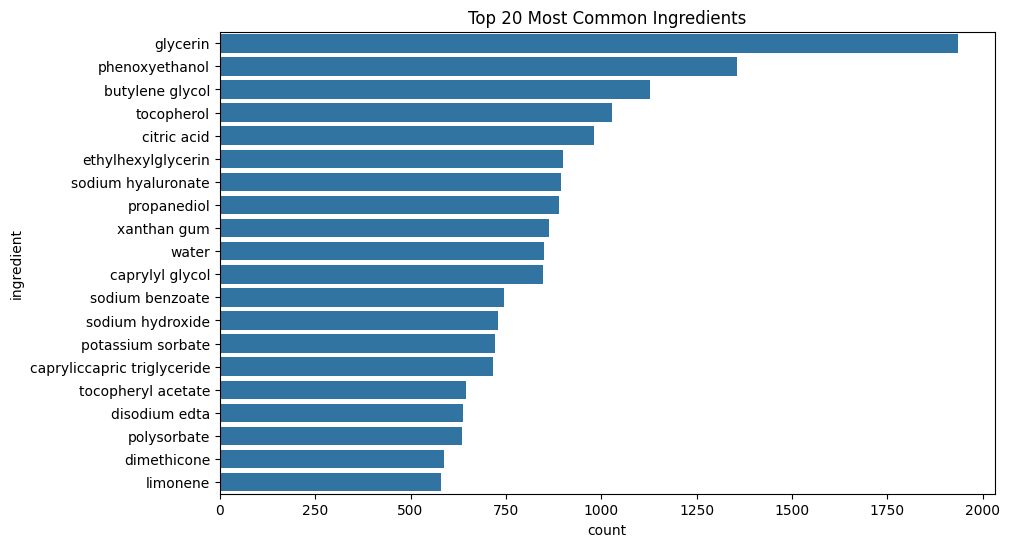

In [ ]:
top20 = ingredient_freq_df.head(20)

plt.figure(figsize=(10,6))
sns.barplot(data=top20, x="count", y="ingredient")
plt.title("Top 20 Most Common Ingredients")
plt.show()

In [ ]:
top_ingredients = ingredient_freq_df.head(30)["ingredient"].tolist()

for ingredient in top_ingredients:
    product_df[ingredient] = product_df["ingredient_list"].apply(
        lambda x: 1 if ingredient in x else 0
    )

In [ ]:
ingredient_lift_results = []

for ingredient in top_ingredients:
    present = product_df[product_df[ingredient] == 1]["rating"]
    absent = product_df[product_df[ingredient] == 0]["rating"]

    lift = present.mean() - absent.mean()

    ingredient_lift_results.append({
        "ingredient": ingredient,
        "avg_rating_present": present.mean(),
        "avg_rating_absent": absent.mean(),
        "lift": lift,
        "count_present": present.count()
    })

ingredient_lift_df = pd.DataFrame(ingredient_lift_results)
ingredient_lift_df = ingredient_lift_df.sort_values(by="lift", ascending=False)

ingredient_lift_df.head(10)

,ingredient,avg_rating_present,avg_rating_absent,lift,count_present
23,hexanediol,4.307248,4.223411,0.083838,464
28,helianthus annuus seed oil,4.291859,4.231699,0.060159,350
22,wateraquaeau,4.288877,4.228919,0.059958,451
19,limonene,4.286499,4.227648,0.058851,506
3,tocopherol,4.274945,4.216366,0.058579,923
12,sodium hydroxide,4.264381,4.231421,0.032960,657
21,squalane,4.264991,4.234124,0.030867,513
4,citric acid,4.256005,4.231184,0.024821,893
20,linalool,4.259545,4.236170,0.023375,489
27,cetearyl alcohol,4.260165,4.236870,0.023295,426


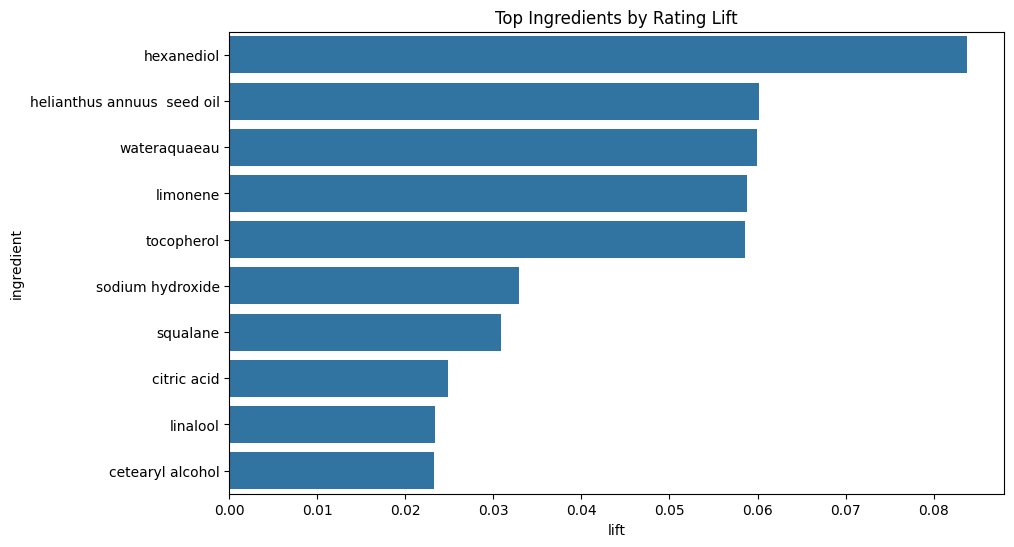

In [ ]:
top_lift = ingredient_lift_df.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_lift, x="lift", y="ingredient")
plt.title("Top Ingredients by Rating Lift")
plt.show()

In [ ]:
ingredient_lift_df = ingredient_lift_df[ingredient_lift_df["count_present"] > 20]

### Multivariate Linear Regression Model

**Feature Engineering**

In [ ]:
def clean_highlights(val):
    if pd.isna(val) or str(val).strip() in ["", "[]"]:
        return []
    cleaned = re.sub(r"[\[\]'\"]", "", str(val))
    return [h.strip().lower() for h in cleaned.split(",") if h.strip()]

product_df["highlight_list"] = product_df["highlights"].apply(clean_highlights)

# Count number of products for each highlight
all_highlights = [h for sublist in product_df["highlight_list"] for h in sublist]
highlight_counts = Counter(all_highlights)

# Show all highlights and their frequency before deciding which to keep
hl_freq_df = pd.DataFrame(highlight_counts.items(), columns=["highlight", "n_products"]).sort_values("n_products", ascending=False).reset_index(drop=True)
hl_freq_df

In [ ]:
selected_highlights = hl_freq_df[hl_freq_df["n_products"] >= 15]["highlight"].tolist()

highlights_cols = []
for hl in selected_highlights:
    col = "hl_" + re.sub(r"[^a-z0-9]", "_", hl).strip("_")
    product_df[col] = product_df["highlight_list"].apply(lambda x: int(hl in x))
    highlights_cols.append(col)

print(selected_highlights)

In [ ]:
reliable_ingredients = ingredient_lift_df["ingredient"].tolist()
print(reliable_ingredients)

# Confirm all these columns exist in product_df
missing = [i for i in reliable_ingredients if i not in product_df.columns]
if missing:
    print(f"\nWARNING: These ingredient columns are missing from product_df: {missing}")
else:
    print("\nAll ingredient columns confirmed in product_df.")

In [ ]:
# Features:
feature_cols = ["price_usd"] + reliable_ingredients + highlights_cols
model_df = product_df[["product_id", "product_name", "rating"] + feature_cols].dropna().reset_index(drop=True)

y = model_df["rating"]
X = model_df[feature_cols]

print(f"Products in regression: {len(model_df)}")
print(f"Total features: {len(feature_cols)}")
print(f"price: 1")
print(f"ingredient cols: {len(reliable_ingredients)}")
print(f"highlight cols: {len(highlights_cols)}")
print(f"\nTarget variable (rating) summary:")
print(y.describe().round(4))

**Multivariate Linear Regression Model Build**

In [ ]:
import statsmodels.api as sm
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

In [ ]:
# Fit OLS via statsmodels — provides coefficients, p-values, and confidence intervals
X_const = sm.add_constant(X)
ols_model = sm.OLS(y, X_const).fit()
print(ols_model.summary())

In [ ]:
# In-sample fit metrics
print("====== In-Sample Fit ======")
print(f"R²: {ols_model.rsquared:.4f}")
print(f"Adj. R²: {ols_model.rsquared_adj:.4f}")
print(f"AIC: {ols_model.aic:.2f}")
print(f"BIC: {ols_model.bic:.2f}")
print(f"p-value: {ols_model.f_pvalue:.4f}")
print()
print("Interpretation:")
print(f"The model explains {ols_model.rsquared*100:.1f}% of the variance in product ratings.")
if ols_model.f_pvalue < 0.05:
    print("The overall model is statistically significant (F p-value < 0.05).")
else:
    print("The overall model is NOT statistically significant (F p-value >= 0.05).")

In [ ]:
# 5-fold cross-validated RMSE
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lr = LinearRegression()

cv_r2   = cross_val_score(lr, X, y, cv=kf, scoring="r2")
cv_rmse = np.sqrt(-cross_val_score(lr, X, y, cv=kf, scoring="neg_mean_squared_error"))

print("====== 5-Fold Cross-Validated Performance ======")
print(f"Cross-Validated R²: {cv_r2.mean():.4f}  (std: {cv_r2.std():.4f})")
print(f"Cross-Validated RMSE: {cv_rmse.mean():.4f}  (std: {cv_rmse.std():.4f}) rating points")
print()
print("Interpretation:")
print(f"On unseen products, the model's predictions are off by ~{cv_rmse.mean():.2f} rating points on average.")
print(f"(Rating scale is 1–5, so this represents ~{cv_rmse.mean()/4*100:.1f}% of the full range.)")

**Coefficient Analysis**

In [ ]:
coefficient_df = pd.DataFrame({
    "feature": ols_model.params.index,
    "coef": ols_model.params.values,
    "lower": ols_model.conf_int()[0].values,
    "upper": ols_model.conf_int()[1].values,
    "pvalue": ols_model.pvalues.values
}).query("feature != 'const'").reset_index(drop=True)

coefficient_df["feature_label"] = (
    coefficient_df["feature"]
    .str.replace("hl_", "[highlight] ", regex=False)
    .str.replace("_", " ", regex=False)
    .str.strip()
)
coefficient_df["significant"] = coefficient_df["pvalue"] < 0.05
coefficient_df = coefficient_df.sort_values("coef", ascending=False).reset_index(drop=True)

significant_df = coefficient_df[coefficient_df["significant"]]
print(f"Significant predictors (p < 0.05): {len(significant_df)} of {len(coefficient_df)} features")
print()
display(significant_df[["feature_label", "coef", "lower", "upper", "pvalue"]].round(4).reset_index(drop=True))

In [ ]:
# Coefficient plot — all features, significant ones highlighted in blue
colors = ["steelblue" if s else "#cccccc" for s in coefficient_df["significant"]]

fig, ax = plt.subplots(figsize=(10, max(7, len(coefficient_df) * 0.35)))
ax.barh(
    coefficient_df["feature_label"], coefficient_df["coef"],
    color=colors,
    xerr=[coefficient_df["coef"] - coefficient_df["lower"], coefficient_df["upper"] - coefficient_df["coef"]],
    capsize=3, error_kw={"linewidth": 0.8, "ecolor": "gray"}
)
ax.axvline(0, color="black", linewidth=0.9, linestyle="--")
ax.set_title(
    "Multivariate Regression Coefficients with 95% Confidence Intervals\n"
    "Blue = significant (p < 0.05)  |  Gray = not significant",
    fontsize=11
)
ax.set_xlabel("Coefficient (effect on predicted rating, 1–5 scale)")
plt.tight_layout()
plt.show()

In [ ]:
# Price coefficient — does price still matter after controlling for ingredients?
price_row = coefficient_df[coefficient_df["feature"] == "price_usd"].iloc[0]
print("====== Price Effect (controlling for ingredients & highlights) ======")
print(f"Coefficient: {price_row['coef']:+.5f} rating points per $1")
print(f"95% Confidence Interval: [{price_row['lower']:+.5f}, {price_row['upper']:+.5f}]")
print(f"p-value: {price_row['pvalue']:.4f}")
print(f"Significant: {'YES' if price_row['significant'] else 'NO'} at alpha = 0.05")
print()
print(f"=> A $10 increase in price is associated with a",
      f"{price_row['coef']*10:+.4f}-point change in predicted rating,")
print("after holding all ingredient and highlight features constant.")

In [ ]:
fitted = ols_model.fittedvalues
residuals = ols_model.resid

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Residuals vs Fitted
axes[0].scatter(fitted, residuals, alpha=0.35, color="steelblue", edgecolors='none', s=15)
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_title("Residuals vs Fitted Values")
axes[0].set_xlabel("Fitted Rating")
axes[0].set_ylabel("Residual")

# 2. Residual histogram
axes[1].hist(residuals, bins=30, color="steelblue", edgecolor="white")
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")

# 3. Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Normal Q-Q Plot")

plt.suptitle("Regression Diagnostics", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

sw_stat, sw_p = stats.shapiro(residuals.sample(min(500, len(residuals)), random_state=42))
print(f"Shapiro-Wilk test (normality of residuals): W = {sw_stat:.4f}, p = {sw_p:.4f}")
print("p > 0.05 suggests residuals are approximately normal (OLS assumption satisfied).")

### Predict Using Model

In [ ]:
fitted = ols_model.fittedvalues
residuals = ols_model.resid
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Residuals vs Fitted
axes[0].scatter(fitted, residuals, alpha=0.35, color="steelblue", edgecolors='none', s=15)
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_title("Residuals vs Fitted Values")
axes[0].set_xlabel("Fitted Rating")
axes[0].set_ylabel("Residual")

# 2. Residual histogram
axes[1].hist(residuals, bins=30, color="steelblue", edgecolor="white")
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")

# 3. Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Normal Q-Q Plot")

plt.suptitle("Regression Diagnostics", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

sw_stat, sw_p = stats.shapiro(residuals.sample(min(500, len(residuals)), random_state=42))
print(f"Shapiro-Wilk test (normality of residuals): W = {sw_stat:.4f}, p = {sw_p:.4f}")
print("  p > 0.05 suggests residuals are approximately normal (OLS assumption satisfied).")

In [ ]:
# Predict using new product features:
new_price = 45.00
new_ingredients = ["glycerin", "water"]
new_highlights = ["vegan", "clean"]

# Build the feature vector for this product
new_row = {"price_usd": new_price}
for ingredient in reliable_ingredients:
    new_row[ingredient] = int(ingredient in [i.lower().strip() for i in new_ingredients])

for highlight, col in zip(selected_highlights, highlights_cols):
    new_row[col] = int(highlight in [h.lower().strip() for h in new_highlights])

new_X = pd.DataFrame([new_row])[feature_cols]
new_X_const = sm.add_constant(new_X, has_constant='add')
prediction = ols_model.predict(new_X_const)[0]
pred_ci = ols_model.get_prediction(new_X_const).conf_int(alpha=0.05)[0]
matched_ingredients = [i for i in reliable_ingredients if new_row[i] == 1]
matched_highlights  = [h for h, col in zip(selected_highlights, highlights_cols) if new_row[col] == 1]

print("PREDICTED PRODUCT RATING")
print(f"Price: ${new_price:.2f}")
print(f"Matched ingredients: {matched_ingredients if matched_ingredients else 'none matched'}")
print(f"Matched highlights: {matched_highlights if matched_highlights else 'none'}")
print()
print(f"Predicted Rating: {prediction:.3f} / 5.0")
print(f"95% Prediction Interval: [{pred_ci[0]:.3f}, {pred_ci[1]:.3f}]")

extra

In [ ]:
# Assemble feature matrix
feature_cols = ["price_usd"] + ing_cols + hl_cols
model_df = final_df[["product_id", "product_name", "rating"] + feature_cols].dropna().reset_index(drop=True)

y  = model_df["rating"]
X1 = model_df[["price_usd"]]
X2 = model_df[["price_usd"] + ing_cols]
X3 = model_df[["price_usd"] + ing_cols + hl_cols]

print(f"Products in regression: {len(model_df)}")
print(f"Model 1 features: {X1.shape[1]}  |  Model 2: {X2.shape[1]}  |  Model 3: {X3.shape[1]}")

In [ ]:
# Fit OLS models via statsmodels (provides p-values and confidence intervals)
def fit_ols(X, y):
    return sm.OLS(y, sm.add_constant(X)).fit()

ols1 = fit_ols(X1, y)
ols2 = fit_ols(X2, y)
ols3 = fit_ols(X3, y)

print("Models fitted.")
for name, m in [("Model 1", ols1), ("Model 2", ols2), ("Model 3", ols3)]:
    print(f"  {name} — R²: {m.rsquared:.4f}  Adj. R²: {m.rsquared_adj:.4f}")

In [ ]:
# Full statistical summary for Model 3
print(ols3.summary())

**Model Comparison**

In [ ]:
# Side-by-side fit metrics
comparison = pd.DataFrame({
    "Model": ["1 — Price Only", "2 — Price + Ingredients", "3 — Full"],
    "R²":      [ols1.rsquared, ols2.rsquared, ols3.rsquared],
    "Adj R²":  [ols1.rsquared_adj, ols2.rsquared_adj, ols3.rsquared_adj],
    "AIC":     [ols1.aic, ols2.aic, ols3.aic],
    "BIC":     [ols1.bic, ols2.bic, ols3.bic],
    "F p-val": [ols1.f_pvalue, ols2.f_pvalue, ols3.f_pvalue],
}).set_index("Model").round(4)
print(comparison.to_string())

In [ ]:
# 5-fold cross-validated RMSE
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []
for label, X in [("Model 1", X1), ("Model 2", X2), ("Model 3", X3)]:
    lr   = LinearRegression()
    r2   = cross_val_score(lr, X, y, cv=kf, scoring="r2")
    rmse = np.sqrt(-cross_val_score(lr, X, y, cv=kf, scoring="neg_mean_squared_error"))
    cv_rows.append({"Model": label, "CV R²": round(r2.mean(), 4),
                    "CV RMSE": round(rmse.mean(), 4), "CV RMSE std": round(rmse.std(), 4)})

cv_df = pd.DataFrame(cv_rows).set_index("Model")
print("5-Fold Cross-Validated Performance:")
print(cv_df.to_string())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
model_labels = ["Model 1\n(Price)", "Model 2\n(+Ingredients)", "Model 3\n(Full)"]
palette = ["#4C9BE8", "#2E6DA4", "#1A3F60"]

r2_vals   = [ols1.rsquared, ols2.rsquared, ols3.rsquared]
rmse_vals = [cv_df.loc[m, "CV RMSE"] for m in ["Model 1", "Model 2", "Model 3"]]

for ax, vals, title, ylabel in [
    (axes[0], r2_vals,   "In-Sample R² by Model", "R²"),
    (axes[1], rmse_vals, "5-Fold CV RMSE (lower = better)", "RMSE (rating points)")
]:
    bars = ax.bar(model_labels, vals, color=palette)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals) * 1.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(vals)*0.01,
                f"{v:.4f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()